In [2]:
import pandas as pd
file_path = "../data/PS_20174392719_1491204439457_log.csv"

df_sample = pd.read_csv(file_path, nrows=5)

df_sample

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## Load the Complete Dataset

The complete PaySim dataset is loaded to check the total number of transactions and columns.


In [3]:
df = pd.read_csv(file_path)

print("Total rows:", df.shape[0])
print("Total columns:", df.shape[1])

Total rows: 6362620
Total columns: 11


## Check Columns and Data Types

This section checks the column names and data types in the PaySim dataset.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


## Check Missing Values

This section checks whether any columns contain missing values.

In [5]:
missing_values = df.isnull().sum()

missing_values

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

## Check Duplicate Transactions

This section checks whether any complete transaction rows are repeated in the dataset.

In [6]:
duplicate_rows = df.duplicated().sum()

print("Total duplicate rows:", duplicate_rows)

Total duplicate rows: 0


### Duplicate Check Result

The dataset contains 0 duplicate rows. Therefore, no duplicate transactions need to be removed.

## Fraud Transaction Distribution

This section checks the number of fraudulent and non-fraudulent transactions in the dataset.

In [7]:
fraud_counts = df["isFraud"].value_counts()

print("Non-fraud transactions:", fraud_counts[0])
print("Fraud transactions:", fraud_counts[1])

Non-fraud transactions: 6354407
Fraud transactions: 8213


### Fraud Percentage and Class Imbalance

This section calculates the percentage of fraudulent transactions and measures the imbalance between fraud and non-fraud cases.

In [8]:
total_transactions = len(df)

non_fraud_percentage = (
    fraud_counts[0] / total_transactions
) * 100

fraud_percentage = (
    fraud_counts[1] / total_transactions
) * 100

imbalance_ratio = fraud_counts[0] / fraud_counts[1]

print("Non-fraud percentage:", round(non_fraud_percentage, 4), "%")
print("Fraud percentage:", round(fraud_percentage, 4), "%")
print("Imbalance ratio:", round(imbalance_ratio, 2), "normal transactions for every fraud transaction")

Non-fraud percentage: 99.8709 %
Fraud percentage: 0.1291 %
Imbalance ratio: 773.7 normal transactions for every fraud transaction


## Visualise Fraud Class Distribution

This chart compares fraudulent and non-fraudulent transaction counts. A logarithmic scale is used because the dataset is extremely imbalanced.

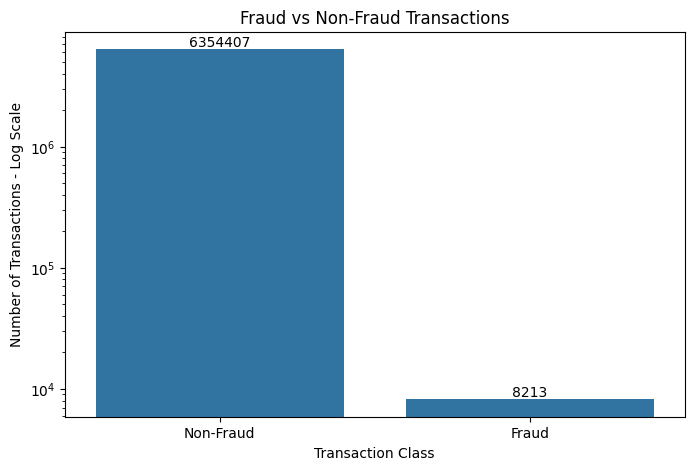

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

fraud_plot = pd.DataFrame({
    "Transaction Class": ["Non-Fraud", "Fraud"],
    "Count": [fraud_counts[0], fraud_counts[1]]
})

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=fraud_plot,
    x="Transaction Class",
    y="Count"
)

plt.yscale("log")

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions - Log Scale")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.show()

### Fraud Distribution Insight

The dataset is highly imbalanced. There are 6,354,407 non-fraud transactions and only 8,213 fraud transactions.

Fraud represents only 0.1291% of all transactions. This means a machine-learning model could achieve very high accuracy by predicting every transaction as non-fraud while failing to detect actual fraud.

Therefore, model performance will be evaluated using fraud-focused metrics such as precision, recall, F1-score, confusion matrix, ROC-AUC, and PR-AUC rather than accuracy alone.